In [1]:
from quicklook.inject import (
    InjectionParams,
    run_grid,
    select_best_window
)

In [2]:
import lightkurve as lk

res = lk.search_lightcurve("TOI-837", author="tglc")
res

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 10,2019,TGLC,1800,460205581,0.0
1,TESS Sector 11,2019,TGLC,1800,460205581,0.0
2,TESS Sector 10,2019,TGLC,1800,847769574,0.0
3,TESS Sector 11,2019,TGLC,1800,847769574,0.0


<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

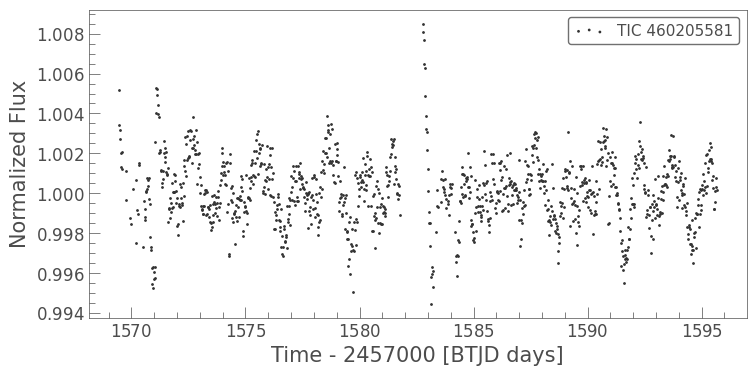

In [3]:
lc = res[0].download()
lc.scatter()

In [4]:
import numpy as np
time, flux = lc.time.value, lc.flux.value

np.random.default_rng(1)
baseline = time[-1]-time[0]
half_baseline = baseline/2
Nmodels = 5
t0s = np.random.uniform(low=0, high=half_baseline, size=Nmodels)
periods = np.random.uniform(low=0.1, high=half_baseline, size=Nmodels)
durations = np.random.uniform(low=0.05, high=0.5, size=Nmodels)
depths = np.random.uniform(low=0.005, high=0.05, size=Nmodels)

In [5]:
windows = np.linspace(0.1, 0.5, 5)

# Several injection epochs for robustness
injections = []
for t0, p, dur, depth in zip(t0s,periods,durations,depths):
    injections.append(InjectionParams(t0=time[0] + t0, period=p, duration=dur, depth=depth))

# Run grid
method = 'biweight'
df = run_grid(time, flux, windows, injections, method=method)

# Select optimal window
best_window, valid = select_best_window(df)
print("Selected window length:", best_window)

transit:   0%|                                                                                                                                                                                  | 0/5 [00:00<?, ?it/s]/ut3/jerome/miniconda3/envs/ql/lib/python3.10/site-packages/transitleastsquares/stats.py:458: RuntimeWarning: divide by zero encountered in double_scalars
  snr_pink_per_transit[i] = (1 - mean_flux) / pinknoise

transit:  40%|████████████████████████████████████████████████████████████████████                                                                                                      | 2/5 [00:17<00:26,  8.69s/it]/ut3/jerome/miniconda3/envs/ql/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/ut3/jerome/miniconda3/envs/ql/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_di

Selected window length: 0.5



/mnt_ut2/raid_ut2/home/jerome/github/research/project/quicklook/quicklook/inject.py:143: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good["score"] = (


In [6]:
from wotan import flatten

In [7]:
flat, trend = flatten(
        time,
        flux,
        method="biweight",
        window_length=best_window,
        return_trend=True,
    )

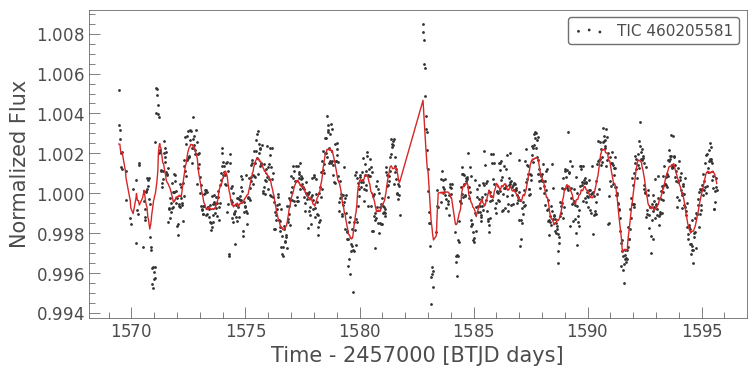

In [8]:
%matplotlib inline

ax = lc.scatter()
ax.plot(time, trend, c='C3')
# ax.plot(time, trend2, c='C0')

In [9]:
from transitleastsquares import transitleastsquares
import matplotlib.pyplot as plt

# Run TLS
tls = transitleastsquares(time, flat)
results = tls.power(verbose=False)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2374/2374 periods | 00:06<00:00


In [10]:
results['Porb_min'] = 1
results['Porb_max'] = 13

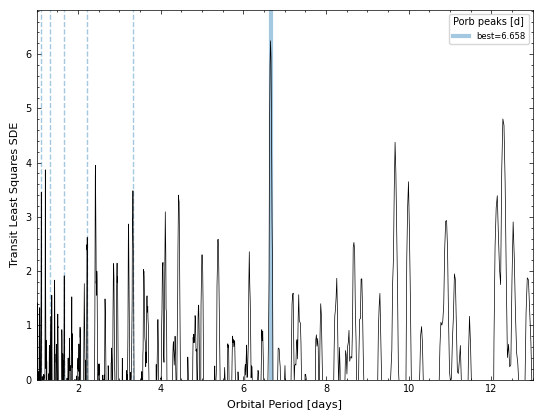

In [11]:
from quicklook.tql import plot_tls

ax = plot_tls(results, period_min=1, period_max=13)

In [12]:
lc_flat = lc.copy()
lc_flat['flux'] = flat

(-0.2, 0.2)

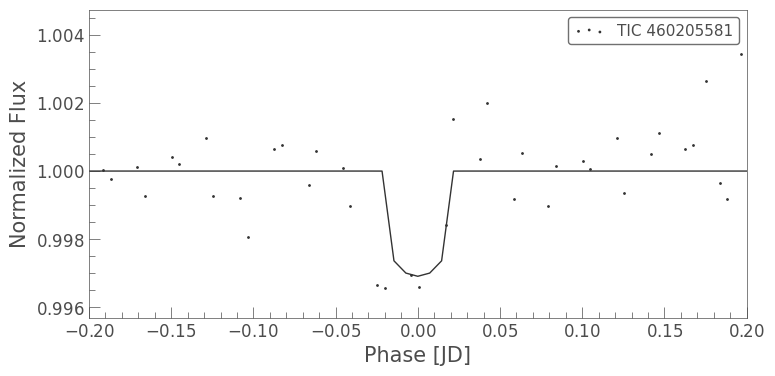

In [13]:
fold = lc_flat.fold(results['period'], results['T0'])
ax = fold.scatter()
ax.plot((results.model_folded_phase - 0.5) * results.period,
        results.model_folded_model)
ax.set_xlim(-0.2,0.2)